# Libraries

In [17]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider
import os
import pandas as pd
import json
from scipy.spatial import Delaunay
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull
import math

# Normalize loaded files

In [32]:
def load_signal_json(filepath):
    """
    Charge un fichier JSON et normalise automatiquement
    les structures Dex pour garantir un accès du type:
    data[...][TD_key]["Dex_2.2"]
    """

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    def normalize(obj):
        """
        Fonction récursive qui parcourt toute la structure
        et convertit les listes Dex en dictionnaires Dex_X.
        """

        # Si c'est un dictionnaire → on parcourt récursivement
        if isinstance(obj, dict):
            return {k: normalize(v) for k, v in obj.items()}

        # Si c'est une liste → on teste si c’est une liste Dex
        if isinstance(obj, list):

            # Cas typique: liste de dicts contenant une clé 'Dex'
            if all(isinstance(e, dict) and "Dex" in e for e in obj):
                new_dict = {}
                for entry in obj:
                    dex_val = entry["Dex"]
                    new_dict[f"Dex_{dex_val}"] = normalize(entry)
                return new_dict

            # Sinon on normalise simplement les éléments
            return [normalize(e) for e in obj]

        return obj  # types simples

    return normalize(data)

# Extraction of parameters from file

In [18]:
H_E=[1, 2]
Patient=[1, 3]
expansion=[3, 3.5, 4]

dir=os.getcwd()
full_path_dir=os.path.join(dir, "Qupath_project", "text_data")

for pat_id in Patient:
    cell_area_pat=0
    cell_max_cal_pat=0
    cell_min_cal_pat=0
    r2D_pat=0
    r3D_pat=0
    den=0
    for he in H_E:
        for coef in expansion:
            text_file=f"Patient_{pat_id}_H&E_{he}_exp_{coef}.txt"
            file_path=os.path.join(full_path_dir, text_file)
            if not os.path.exists(file_path):
                print(f"No file named {text_file} in {full_path_dir}")
                continue
            den+=1
            df = pd.read_csv(file_path, sep='\t', engine='python')
            cell_area=df["Cell: Area"].to_numpy()
            cell_max_cal=df["Cell: Max caliper"].to_numpy()
            cell_min_cal=df["Cell: Min caliper"].to_numpy()

            '''
            plt.figure(figsize=(15, 4))

            plt.subplot(1, 3, 1)
            plt.hist(cell_area, bins=30, color='skyblue', edgecolor='black')
            plt.title(f"Cell Area patient {pat_id} H&E {he} cell expansion of {coef} µm")
            plt.xlabel("µm²")
            plt.ylabel("Nombre de cellules")

            plt.subplot(1, 3, 2)
            plt.hist(cell_max_cal, bins=30, color='lightgreen', edgecolor='black')
            plt.title(f"Cell Max Caliper patient {pat_id} H&E {he} cell expansion of {coef} µm")
            plt.xlabel("µm")

            plt.subplot(1, 3, 3)
            plt.hist(cell_min_cal, bins=30, color='salmon', edgecolor='black')
            plt.title(f"Cell Min Caliper patient {pat_id} H&E {he} cell expansion of {coef} µm")
            plt.xlabel("µm")

            plt.tight_layout()
            plt.show()
            '''

            mean_cell_area=np.mean(cell_area)
            mean_cell_max_cal=np.mean(cell_max_cal)
            mean_cell_min_cal=np.mean(cell_min_cal)

            std_cell_area=np.std(cell_area)
            std_cell_max_cal=np.std(cell_max_cal)
            std_cell_min_cal=np.std(cell_min_cal)

            r2D=np.sqrt(mean_cell_min_cal*mean_cell_max_cal/4)
            std_r2D = 0.25 * np.sqrt((mean_cell_max_cal / mean_cell_min_cal) * std_cell_min_cal**2+ (mean_cell_min_cal / mean_cell_max_cal) * std_cell_max_cal**2)
            r3D=1.27*r2D
            std_r3D=1.27*std_r2D

            print("---------Statistics---------")
            print(f"Mean cell area = {mean_cell_area:.2f} µm²")
            print(f"Mean max caliper = {mean_cell_max_cal:.2f} µm")
            print(f"Mean min caliper = {mean_cell_min_cal:.2f} µm")
            print(f"Equivalent average 2D radius {r2D:.2f} µm and 2D standard deviation {std_r2D:.2f} µm")
            print(f"Equivalent average 3D radius: {r3D:.2f} µm and 3D standard deviation {std_r3D:.2f} µm")

            cell_area_pat+=mean_cell_area
            cell_max_cal_pat+=mean_cell_max_cal
            cell_min_cal_pat+=mean_cell_min_cal
            r2D_pat+=r2D
            r3D_pat+=r3D


    cell_area_pat=cell_area_pat/den
    cell_max_cal_pat=cell_max_cal_pat/den
    cell_min_cal_pat=cell_min_cal_pat/den
    r2D_pat=r2D_pat/den
    r3D_pat=r3D_pat/den

    print(f"---------Statistics Patient {pat_id}---------")
    print(f"Mean cell area = {cell_area_pat:.2f} µm²")
    print(f"Mean max caliper = {cell_max_cal_pat:.2f} µm")
    print(f"Mean min caliper = {cell_min_cal_pat:.2f} µm")
    print(f"Equivalent average 2D radius {r2D_pat:.2f} µm")
    print(f"Equivalent average 3D radius: {r3D_pat:.2f} µm")




---------Statistics---------
Mean cell area = 85.68 µm²
Mean max caliper = 12.14 µm
Mean min caliper = 9.14 µm
Equivalent average 2D radius 5.27 µm and 2D standard deviation 0.67 µm
Equivalent average 3D radius: 6.69 µm and 3D standard deviation 0.85 µm
---------Statistics---------
Mean cell area = 90.39 µm²
Mean max caliper = 12.54 µm
Mean min caliper = 9.37 µm
Equivalent average 2D radius 5.42 µm and 2D standard deviation 0.70 µm
Equivalent average 3D radius: 6.88 µm and 3D standard deviation 0.89 µm
---------Statistics---------
Mean cell area = 95.39 µm²
Mean max caliper = 12.97 µm
Mean min caliper = 9.59 µm
Equivalent average 2D radius 5.58 µm and 2D standard deviation 0.75 µm
Equivalent average 3D radius: 7.08 µm and 3D standard deviation 0.95 µm
---------Statistics---------
Mean cell area = 104.77 µm²
Mean max caliper = 13.14 µm
Mean min caliper = 10.21 µm
Equivalent average 2D radius 5.79 µm and 2D standard deviation 0.71 µm
Equivalent average 3D radius: 7.36 µm and 3D standard 

# STD

In [19]:
H_E=[1, 2]
Patient=[1, 3]
expansion=[3, 3.5, 4]

dir=os.getcwd()
full_path_dir=os.path.join(dir, "Qupath_project", "text_data")

for pat_id in Patient:
    all_cell_area = []
    all_cell_max_cal = []
    all_cell_min_cal = []

    for he in H_E:
        for coef in expansion:
            text_file=f"Patient_{pat_id}_H&E_{he}_exp_{coef}.txt"
            file_path=os.path.join(full_path_dir, text_file)

            if not os.path.exists(file_path):
                continue

            df = pd.read_csv(file_path, sep='\t', engine='python')

            all_cell_area.extend(df["Cell: Area"].to_numpy())
            all_cell_max_cal.extend(df["Cell: Max caliper"].to_numpy())
            all_cell_min_cal.extend(df["Cell: Min caliper"].to_numpy())

    all_cell_area = np.array(all_cell_area)
    all_cell_max_cal = np.array(all_cell_max_cal)
    all_cell_min_cal = np.array(all_cell_min_cal)

    mean_cell_area_pat = np.mean(all_cell_area)
    std_cell_area_pat  = np.std(all_cell_area, ddof=1)

    mean_cell_max_cal_pat = np.mean(all_cell_max_cal)
    std_cell_max_cal_pat  = np.std(all_cell_max_cal, ddof=1)

    mean_cell_min_cal_pat = np.mean(all_cell_min_cal)
    std_cell_min_cal_pat  = np.std(all_cell_min_cal, ddof=1)

    r2D_pat = np.sqrt(mean_cell_min_cal_pat * mean_cell_max_cal_pat / 4)

    std_r2D_pat = 0.25 * np.sqrt(
        (mean_cell_max_cal_pat / mean_cell_min_cal_pat) * std_cell_min_cal_pat**2 +
        (mean_cell_min_cal_pat / mean_cell_max_cal_pat) * std_cell_max_cal_pat**2
    )

    r3D_pat = 1.27 * r2D_pat
    std_r3D_pat = 1.27 * std_r2D_pat

    print(f"==== PATIENT STATISTICS {pat_id} ====")
    print(f"Mean area : {mean_cell_area_pat:.2f} ± {std_cell_area_pat:.2f} µm²")
    print(f"Mean max caliper : {mean_cell_max_cal_pat:.2f} ± {std_cell_max_cal_pat:.2f} µm")
    print(f"Mean min caliper : {mean_cell_min_cal_pat:.2f} ± {std_cell_min_cal_pat:.2f} µm")
    print(f"Radius 2D : {r2D_pat:.2f} ± {std_r2D_pat:.2f} µm")
    print(f"Radius 3D : {r3D_pat:.2f} ± {std_r3D_pat:.2f} µm")


==== PATIENT STATISTICS 1 ====
Mean area : 111.43 ± 39.92 µm²
Mean max caliper : 13.61 ± 2.43 µm
Mean min caliper : 10.47 ± 2.08 µm
Radius 2D : 5.97 ± 0.80 µm
Radius 3D : 7.58 ± 1.01 µm
==== PATIENT STATISTICS 3 ====
Mean area : 92.00 ± 31.27 µm²
Mean max caliper : 12.94 ± 2.30 µm
Mean min caliper : 9.32 ± 1.81 µm
Radius 2D : 5.49 ± 0.72 µm
Radius 3D : 6.97 ± 0.92 µm


# ALL

In [47]:
if not os.path.exists("roi_results.json"):
    H_E = [1, 2]
    Patient = [1, 3]
    expansion = [3, 3.5, 4]

    allowed_ROI = {"ROI1", "ROI2", "ROI3", "ROI4"}

    results_json = {}

    dir = os.getcwd()
    full_path_dir = os.path.join(dir, "Qupath_project", "text_data")

    for pat_id in Patient:

        results_json[f"Patient_{pat_id}"] = {}

        for he in H_E:
            results_json[f"Patient_{pat_id}"][f"H&E_{he}"] = {}

            for coef in expansion:

                results_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{coef}"] = {}

                text_file = f"Patient_{pat_id}_H&E_{he}_exp_{coef}.txt"
                file_path = os.path.join(full_path_dir, text_file)

                if not os.path.exists(file_path):
                    continue

                df = pd.read_csv(file_path, sep='\t', engine='python')

                df = df[df["Parent"].isin(allowed_ROI)]

                for roi in sorted(df["Parent"].unique()):

                    df_roi = df[df["Parent"] == roi]

                    area = df_roi["Cell: Area"].to_numpy()
                    max_cal = df_roi["Cell: Max caliper"].to_numpy()
                    min_cal = df_roi["Cell: Min caliper"].to_numpy()

                    mean_area = np.mean(area)
                    std_area = np.std(area, ddof=1)

                    mean_max = np.mean(max_cal)
                    std_max = np.std(max_cal, ddof=1)

                    mean_min = np.mean(min_cal)
                    std_min = np.std(min_cal, ddof=1)

                    r2D = np.sqrt(mean_min * mean_max / 4)

                    std_r2D = 0.25 * np.sqrt(
                        (mean_max / mean_min) * std_min**2 +
                        (mean_min / mean_max) * std_max**2
                    )

                    # Correction factor for 3D radius
                    r3D = 1.27 * r2D
                    std_r3D = 1.27 * std_r2D

                    results_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{coef}"][roi] = {
                        "mean_area": mean_area,
                        "std_area": std_area,
                        "mean_max_caliper": mean_max,
                        "std_max_caliper": std_max,
                        "mean_min_caliper": mean_min,
                        "std_min_caliper": std_min,
                        "mean_r2D": r2D,
                        "std_r2D": std_r2D,
                        "mean_r3D": r3D,
                        "std_r3D": std_r3D
                    }

    # Saving results
    with open("roi_results.json", "w") as f:
        json.dump(results_json, f, indent=4)

    print("JSON generated : roi_results.json")

else:
    with open("roi_results.json", 'r', encoding='utf-8') as f:
        results_json = json.load(f)

    print("ROI results loaded from roi_results.json")


ROI results loaded from roi_results.json


# Cell density with Abercrombie

In [48]:
if not os.path.exists("density_results.json"):
    slice_width=4 #4 um

    density_json={}

    for pat_id in Patient:
        print(f"----------Statistics for patient {pat_id}----------")
        density_json[f"Patient_{pat_id}"] = {}
        for he in H_E:
            print(f"=== H&E {he} ===")
            density_json[f"Patient_{pat_id}"][f"H&E_{he}"] = {}
            for exp in expansion:
                density_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"]={}
                annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
                annot_path = os.path.join(full_path_dir, annot_file)
                if not os.path.exists(annot_path):
                    print(f"No file named {annot_file} in {full_path_dir}")
                    continue

                df_annot = pd.read_csv(annot_path, sep='\t', engine='python')

                # ROIs data
                df_annot_sorted = df_annot.sort_values(by="Name")
                names = df_annot_sorted["Name"].to_numpy()
                areas = df_annot_sorted["Area µm^2"].to_numpy()
                
                # Cell data
                patient_file = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
                patient_path = os.path.join(full_path_dir, patient_file)
                if not os.path.exists(patient_path):
                    print(f"No file named {patient_file} in {full_path_dir}")
                    continue

                df_patient = pd.read_csv(patient_path, sep='\t', engine='python')

                # Quantity calculations
                preliminary_file = "roi_results.json"
                with open(preliminary_file, 'r', encoding='utf-8') as f:
                    preliminary_results=json.load(f)

                for i in range(len(names)):
                    roi_name = names[i]
                    df_roi = df_patient[df_patient["Parent"] == roi_name]
                    cells_area = df_roi["Cell: Area"].to_numpy()
                    if len(cells_area) == 0:
                        print(f"ROI {roi_name} (H&E {he}, exp {exp}) : no cell found")
                        continue

                    density_2d = sum(cells_area) / areas[i]

                    n = len(df_roi)
                    r2D = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["mean_r2D"]
                    sigma_r2D = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["std_r2D"]

                    r3D = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["mean_r3D"]
                    sigma_r3D = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["std_r3D"]

                    # N_v et V_cell
                    N_v = n / ((slice_width + 2*r2D) * areas[i])
                    V_cell = 4*np.pi*(r3D**3)/3
                    density_3d = N_v * V_cell

                    # Uncertainty propagation
                    dN_dr2D = -2 * n / ((slice_width + 2*r2D)**2 * areas[i])
                    dV_dr3D = 4 * np.pi * (r3D**2)

                    sigma_Nv = abs(dN_dr2D) * sigma_r2D
                    sigma_Vcell = abs(dV_dr3D) * sigma_r3D

                    sigma_density3D = np.sqrt((sigma_Nv * V_cell)**2 + (N_v * sigma_Vcell)**2)

                    density_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name] = {
                        "density_2d": round(density_2d, 2),
                        "density_3d": round(density_3d, 2),
                        "sigma_density_3d": round(sigma_density3D, 2)
                    }

                    print(f"{roi_name:<20} | 3D density: {density_3d:>10.2f} ± {sigma_density3D:>6.2f} | 2D density: {density_2d:>10.2f} | Expansion: {exp}")


    # Saving results JSON
    with open("density_results.json", "w") as f:
        json.dump(density_json, f, indent=4)

    print("JSON generated : density_results.json")

else:
    with open("density_results.json", 'r', encoding='utf-8') as f:
        density_json = json.load(f)

    print("Density results loaded from density_results.json")


Density results loaded from density_results.json


# Load the LUT

In [49]:
lut = loadmat('lookup_table_validation_compat.mat') #put the new LUT name
params_lut = lut['params']     
signals_lut = lut['signals_4D']            
sequence_lut = lut['sequence']

params_lut = np.array(params_lut) 
signals_lut = np.array(signals_lut)

# Checking LUT

In [50]:
bval = np.array(sequence_lut['bval'][0][0]).flatten()   # shape: (n_bval,)
TD   = np.array(sequence_lut['TD'][0][0]).flatten()     # shape: (n_del,)
bvecs = np.array(sequence_lut['bvecs'][0][0])           # shape: (n_bvec, 3)
print("params shape:", params_lut.shape)
print("signals shape:", signals_lut.shape)
print("bval:", bval)
print("TD:", TD[:5])
print("bvecs shape:", bvecs.shape)

params shape: (1034, 4)
signals shape: (1034, 2, 16, 64)
bval: [ 0.05  0.2   0.35  0.8   0.95  1.5   2.3   2.4   3.45  4.25  4.75  6.
  6.75  9.85 13.5  18.8 ]
TD: [19. 49.]
bvecs shape: (64, 3)


# Delaunay interpolation

In [51]:
def interpolate_signal(f, Dex, rmean, rsd, bval, TD, tri, signals_lookup, params_lut):
    # Security check for zero density
    if f < 0.007:
        return 1.0

    query_params = np.array([f, Dex, rmean, rsd])
    
    # Get indices for TD and bval (ensure sequence_lut is accessible)
    bvals = sequence_lut['bval'][0][0]
    TDs = sequence_lut['TD'][0][0]
    TD_index = np.where(TDs == TD)[0][0]
    bval_index = np.where(bvals == bval)[0][0]

    # Find the simplex containing the query point
    simplex_index = tri.find_simplex(query_params)

    # OUT OF HULL : Fallback on nearest neighbor
    if simplex_index == -1:
        distances = np.linalg.norm(params_lut - query_params, axis=1)
        nearest_idx = np.argmin(distances)
        signal_nearest = signals_lookup[nearest_idx]
        return np.mean(signal_nearest[TD_index, bval_index, :]) / 1e5

    # IN HULL : Barycentric interpolation
    vertex_index = tri.simplices[simplex_index]
    vertices = params_lut[vertex_index]

    try:
        T = vertices[1:] - vertices[0]
        v = query_params - vertices[0]
        bary_coords = np.linalg.solve(T.T, v)
        bary_coords = np.append(1 - np.sum(bary_coords), bary_coords)
        
        signals_subset = signals_lookup[vertex_index]
        interpolated_signal = np.tensordot(bary_coords, signals_subset, axes=(0, 0))
        return np.mean(interpolated_signal[TD_index, bval_index, :]) / 1e5
    except:
        # Fallback to nearest neighbor in case of numerical issues
        distances = np.linalg.norm(vertices - query_params, axis=1)
        nearest_v_idx = vertex_index[np.argmin(distances)]
        return np.mean(signals_lookup[nearest_v_idx][TD_index, bval_index, :]) / 1e5

# Uncertainty calculation 

In [52]:
def get_signal_with_uncertainty(f_mean, f_std, rmean_val, rsd_val, Dex_central, bval, TD, tri, signals_lookup, params_lut, n_samples=100):
    """
    Function to get signal with uncertainty estimation by sampling parameters from a uniform distribution 
    around their mean ± 2*std (95% confidence interval).
    """
    lut_min = np.min(params_lut, axis=0)
    lut_max = np.max(params_lut, axis=0)
    print(lut_min, lut_max)
    
    signals_sim = []
    # Uniform (confidence interval ~95% : +/- 2*sigma)
    f_range = (max(lut_min[0], f_mean - 2*f_std), min(lut_max[0], f_mean + 2*f_std))
    rm_range = (max(lut_min[2], rmean_val - 2*rsd_val), min(lut_max[2], rmean_val + 2*rsd_val))
    rs_range = (max(lut_min[3], rsd_val - 0.2*rsd_val), min(lut_max[3], rsd_val + 0.2*rsd_val))
    d_range = (max(lut_min[1], Dex_central - 0.2), min(lut_max[1], Dex_central + 0.2))

    for _ in range(n_samples):
        # Random sampling: no assumption on distribution shape
        f_n = np.random.uniform(*f_range)
        r_m_n = np.random.uniform(*rm_range)
        r_s_n = np.random.uniform(*rs_range)
        d_n = np.random.uniform(*d_range)

        # Interpolation
        sig = interpolate_signal(f_n, d_n, r_m_n, r_s_n, bval, TD, tri, signals_lookup, params_lut)
        
        if not np.isnan(sig):
            signals_sim.append(sig)
    
    if not signals_sim:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # Percentiles for 95% confidence interval
    mean_sig = np.mean(signals_sim)
    std_sig = np.std(signals_sim)
    median_sig = np.median(signals_sim)
    p_low = np.percentile(signals_sim, 2.5)
    p_high = np.percentile(signals_sim, 97.5)
            
    return mean_sig, std_sig, median_sig, p_low, p_high

# Uncertainty with shrinkage

In [53]:
def get_signal_with_uncertainty_shrinkage(f_mean, f_std, rmean_val, rsd_val, Dex_central, 
                                         bval, TD, tri, signals_lookup, params_lut, 
                                         shrinkage_factor=1.0, n_samples=100):
    """
    Function to get signal with uncertainty estimation by sampling parameters from a uniform distribution 
    around their mean ± 2*std (95% confidence interval), with an optional shrinkage factor applied to the parameters to simulate the effect of histological shrinkage.
    """
    lut_min = np.min(params_lut, axis=0)
    lut_max = np.max(params_lut, axis=0)
    
    # --- SHRINKAGE ---
    f_mean_corr = f_mean * shrinkage_factor
    f_std_corr  = f_std * shrinkage_factor
    
    rmean_corr  = rmean_val #* (shrinkage_factor**(1/3))
    rsd_corr    = rsd_val #* (shrinkage_factor**(1/3))
    
    signals_sim = []
    
    # Range definition 
    f_range = (max(lut_min[0], f_mean_corr - 2*f_std_corr), 
               min(lut_max[0], f_mean_corr + 2*f_std_corr))
    
    rm_range = (max(lut_min[2], rmean_corr - 2*rsd_corr), 
                min(lut_max[2], rmean_corr + 2*rsd_corr))
    
    rs_range = (max(lut_min[3], rsd_corr * 0.8), min(lut_max[3], rsd_corr * 1.2))
    d_range = (max(lut_min[1], Dex_central - 0.2), min(lut_max[1], Dex_central + 0.2))

    for i in range(n_samples):

        np.random.seed(i) 
        f_n = np.random.uniform(*f_range)
        r_m_n = np.random.uniform(*rm_range)
        r_s_n = np.random.uniform(*rs_range)
        d_n = np.random.uniform(*d_range)

        #f_n = f_mean_corr
        #r_m_n = rmean_corr
        #r_s_n = rsd_corr
        #d_n = Dex_central # We can choose to fix Dex to isolate the effect of shrinkage on histological parameters
        
        sig = interpolate_signal(f_n, d_n, r_m_n, r_s_n, bval, TD, tri, signals_lookup, params_lut)
        
        if not np.isnan(sig):
            signals_sim.append(sig)
    
    if not signals_sim:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # Percentiles for 95% confidence interval
    mean_sig = np.mean(signals_sim)
    std_sig = np.std(signals_sim)
    median_sig = np.median(signals_sim)
    p_low = np.percentile(signals_sim, 2.5)  
    p_high = np.percentile(signals_sim, 97.5) 
            
    return mean_sig, std_sig, median_sig, p_low, p_high

# Exponential decrease from histology and LUT

In [55]:
if not os.path.exists("signal_results.json"):
    
    # Tissue parameters
    Din=1 #um2/s
    Dex_options=[1.5, 2.2, 2.5] #um2/s
    kappa=0.01 #um/s
    pulse_width=8 #ms
    bval_options=[[0.05, 0.35, 0.8, 1.5, 2.4, 3.45, 4.75, 6],[0.2, 0.95, 2.3, 4.25, 6.75, 9.85, 13.5, 18.8]] #ms/mm2 
    TD_options=[19, 49] #ms
    bvecs_options=[32, 64] #gradient directions
    tri=Delaunay(params_lut)

    signal_json={}

    for pat_id in Patient:
        print(f"----------Graphs for patient {pat_id}----------")
        signal_json[f"Patient_{pat_id}"] = {}
        for he in H_E:
            signal_json[f"Patient_{pat_id}"][f"H&E_{he}"] = {}
            for exp in expansion:
                signal_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"]={}

                annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
                annot_path = os.path.join(full_path_dir, annot_file)
                if not os.path.exists(annot_path):
                    print(f"No file named {annot_file} in {full_path_dir}")
                    continue

                df_annot = pd.read_csv(annot_path, sep='\t', engine='python')

                # ROIs data
                df_annot_sorted = df_annot.sort_values(by="Name")
                names = df_annot_sorted["Name"].to_numpy()

                # Calculated parameters
                preliminary_file = "roi_results.json"
                with open(preliminary_file, 'r', encoding='utf-8') as f:
                    preliminary_results=json.load(f)

                # Densities
                density_file = "density_results.json"
                with open(density_file, 'r', encoding='utf-8') as f:
                    density_results=json.load(f)

                for i in range(len(names)):
                    roi_name = names[i]
                    signal_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]={}
                    
                    # Data retrieval
                    roi_data = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]
                    dens_data = density_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]
                    
                    r_3d_mean = roi_data["mean_r3D"]
                    r_3d_std = roi_data["std_r3D"]
                    f_mean = dens_data["density_3d"]
                    f_sigma = dens_data["sigma_density_3d"]
                                
                    for j in {0, 1}:
                        TD = TD_options[j]
                        signal_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][f"TD_{TD}"]={}
                        
                        for Dex in Dex_options:
                            signals_mean = []
                            signals_std = []
                            signals_median = []
                            p_low_values = []
                            p_high_values = []
                            
                            for bval in bval_options[j]:
                                
                                mean_sig, std_sig, m_sig, p_low_sig, p_high_sig = get_signal_with_uncertainty(
                                    f_mean, f_sigma, r_3d_mean, r_3d_std, Dex, bval, TD, tri, signals_lut, params_lut
                                )
                                signals_mean.append(mean_sig)
                                signals_std.append(std_sig)
                                signals_median.append(m_sig)
                                p_low_values.append(p_low_sig)
                                p_high_values.append(p_high_sig)
                            
                            signal_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][f"TD_{TD}"][f"Dex_{Dex}"] = {
                                "bval": bval_options[j],
                                "signals_mean": signals_mean,
                                "signals_std": signals_std,
                                "signals_median": signals_median,
                                "p_low": p_low_values,
                                "p_high": p_high_values
                            }

    # Saving results JSON
    with open("signal_results.json", "w") as f:
        json.dump(signal_json, f, indent=4)
    print("JSON generated : signal_results.json")

else:
    # If the simulation file already exists
    with open("signal_results.json", 'r', encoding='utf-8') as f:
        signal_json = json.load(f)
        #print(json.dumps(signal_json, indent=4, ensure_ascii=False))

    print("Signal results loaded from signal_results.json")

Signal results loaded from signal_results.json


# Exponential decay simulation with shrinkage

In [56]:
if not os.path.exists("signal_results_shrinkage.json"):

    # Tissue parameters
    Din=1 #um2/s
    Dex_options=[1.5, 2.2, 2.5] #um2/s
    kappa=0.01 #um/s
    pulse_width=8 #ms
    bval_options=[[0.05, 0.35, 0.8, 1.5, 2.4, 3.45, 4.75, 6],[0.2, 0.95, 2.3, 4.25, 6.75, 9.85, 13.5, 18.8]] #ms/mm2 
    TD_options=[19, 49] #ms
    bvecs_options=[32, 64] #gradient directions
    tri=Delaunay(params_lut)

    # --- Shrinkage parameters ---
    shrinkage_factors = [0.5, 0.66, 0.7]

    signal_json_shrinkage = {}

    for pat_id in Patient:
        print(f"----------Graphs for patient {pat_id}----------")
        signal_json_shrinkage[f"Patient_{pat_id}"] = {}
        for he in H_E:
            signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"] = {}
            for exp in expansion:
                signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"] = {}

                annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
                annot_path = os.path.join(full_path_dir, annot_file)
                if not os.path.exists(annot_path):
                    print(f"No file named {annot_file} in {full_path_dir}")
                    continue

                df_annot = pd.read_csv(annot_path, sep='\t', engine='python')

                # Data ROIs
                df_annot_sorted = df_annot.sort_values(by="Name")
                names = df_annot_sorted["Name"].to_numpy()

                # Parameters from previous calculations
                preliminary_file = "roi_results.json"
                with open(preliminary_file, 'r', encoding='utf-8') as f:
                    preliminary_results=json.load(f)

                # Density
                density_file = "density_results.json"
                with open(density_file, 'r', encoding='utf-8') as f:
                    density_results=json.load(f)

                for i in range(len(names)):
                    roi_name = names[i]
                    signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name] = {}
                    
                    roi_data = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]
                    dens_data = density_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]
                    
                    # Raw parameters before shrinkage correction
                    r_3d_mean_raw = roi_data["mean_r3D"]
                    r_3d_std_raw = roi_data["std_r3D"]
                    f_mean_raw = dens_data["density_3d"]
                    f_sigma_raw = dens_data["sigma_density_3d"]

                    # --- SHRINKAGE ---
                    for k in shrinkage_factors:
                        print(f"Calculating for shrinkage factor {k}...")
                        sh_key = f"shrinkage_{k}"
                        signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][sh_key] = {}

                        for j in {0, 1}:
                            TD = TD_options[j]
                            signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][sh_key][f"TD_{TD}"] = {}
                            
                            for Dex in Dex_options:
                                signals_mean, signals_std = [], []
                                signals_median, p_low_values, p_high_values = [], [], []
                                
                                for bval in bval_options[j]:
                                    
                                    print(f"Calculating for Patient {pat_id}, H&E {he}, exp {exp}, ROI {roi_name}, shrinkage {k}, TD {TD}, Dex {Dex}, bval {bval} with the parameters: f_mean_raw={f_mean_raw}, f_sigma_raw={f_sigma_raw}, r_3d_mean_raw={r_3d_mean_raw}, r_3d_std_raw={r_3d_std_raw}")
                                    mean_sig, std_sig, m_sig, p_low_sig, p_high_sig = get_signal_with_uncertainty_shrinkage(
                                        f_mean_raw, f_sigma_raw, r_3d_mean_raw, r_3d_std_raw, 
                                        Dex, bval, TD, tri, signals_lut, params_lut,
                                        shrinkage_factor=k, n_samples=1000
                                    )
                                    
                                    signals_mean.append(mean_sig)
                                    signals_std.append(std_sig)
                                    signals_median.append(m_sig)
                                    p_low_values.append(p_low_sig)
                                    p_high_values.append(p_high_sig)
                                
                                signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][sh_key][f"TD_{TD}"][f"Dex_{Dex}"] = {
                                    "bval": bval_options[j],
                                    "signals_mean": signals_mean,
                                    "signals_std": signals_std,
                                    "signals_median": signals_median,
                                    "p_low": p_low_values,
                                    "p_high": p_high_values,
                                    "applied_params": {"f": f_mean_raw*k} 
                                }

    # Saving results JSON
    output_name = "signal_results_shrinkage.json"
    with open(output_name, "w") as f:
        json.dump(signal_json_shrinkage, f, indent=4)
    print(f"File saved : {output_name}")

else:
    # If the simulation file already exists
    with open("signal_results_shrinkage.json", 'r', encoding='utf-8') as f:
        signal_json_shrinkage = json.load(f)

    print("Shrinkage signal results loaded from signal_results_shrinkage.json")

Shrinkage signal results loaded from signal_results_shrinkage.json


# Extreme geometry

In [58]:
if not os.path.exists("signal_results_geom.json"):
    
    # Tissue parameters
    Din=1 #um2/s
    Dex_options=[1.5, 2.2, 2.5] #um2/s
    kappa=0.01 #um/s
    pulse_width=8 #ms
    bval_options=[[0.05, 0.35, 0.8, 1.5, 2.4, 3.45, 4.75, 6],[0.2, 0.95, 2.3, 4.25, 6.75, 9.85, 13.5, 18.8]] #ms/mm2 
    TD_options=[19, 49] #ms
    bvecs_options=[32, 64] #gradient directions
    tri=Delaunay(params_lut)

    signal_json_geom={}

    # Parameters for extreme geometries
    r_3d_mean = [3, 9]
    r_3d_std = 0.5
    f_mean = [0.1, 0.8]
    f_sigma = 0.02
                                
    for r in r_3d_mean:
        signal_json_geom[f"r_{r}"] = {}
        for f in f_mean:
            signal_json_geom[f"r_{r}"][f"f_{f}"] = {}
            for j in range(len(TD_options)):
                TD = TD_options[j]
                signal_json_geom[f"r_{r}"][f"f_{f}"][f"TD_{TD}"]={}
                
                for Dex in Dex_options:
                    signals_mean = []
                    signals_std = []
                    signals_median = []
                    p_low_values = []
                    p_high_values = []
                    
                    for bval in bval_options[j]:
                        
                        mean_sig, std_sig, m_sig, p_low_sig, p_high_sig = get_signal_with_uncertainty(
                            f, f_sigma, r, r_3d_std, Dex, bval, TD, tri, signals_lut, params_lut, n_samples=1000
                        )
                        signals_mean.append(mean_sig)
                        signals_std.append(std_sig)
                        signals_median.append(m_sig)
                        p_low_values.append(p_low_sig)
                        p_high_values.append(p_high_sig)
                    
                    signal_json_geom[f"r_{r}"][f"f_{f}"][f"TD_{TD}"][f"Dex_{Dex}"] = {
                        "bval": bval_options[j],
                        "signals_mean": signals_mean,
                        "signals_std": signals_std,
                        "signals_median": signals_median,
                        "p_low": p_low_values,
                        "p_high": p_high_values
                    }

        # Saving results JSON
        with open("signal_results_geom.json", "w") as f:
            json.dump(signal_json_geom, f, indent=4)
        print("JSON generated : signal_results_geom.json")

else:
    # If the simulation file already exists
    
    with open("signal_results_geom.json", 'r', encoding='utf-8') as f:
        signal_json_geom = json.load(f)

    print("Signal results loaded from signal_results_geom.json")

Signal results loaded from signal_results_geom.json


# Comparison shrinkage factors

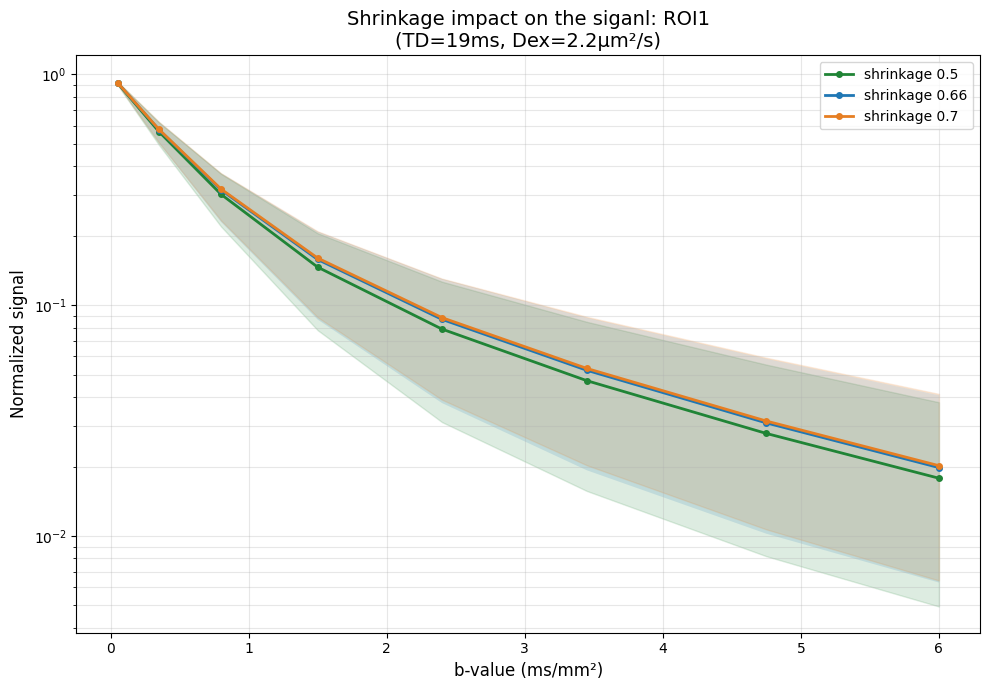

In [59]:
def plot_shrinkage_comparison(signal_json, pat_id, he, exp, roi_name, td_val, dex_val):
    """
    Function to display the impact of shrinkage on the simulated signal for a given ROI, TD and Dex.
    Mean signal and uncertainty (percentiles) are plotted for each shrinkage factor.
    """
    plt.figure(figsize=(10, 7))
    
    colors = {
        "original": "black",
        "shrinkage_0.9": "#1d70a7",
        "shrinkage_0.7": "#e67e22", 
        "shrinkage_0.5": "#208436" 
    }

    # Get the right roi data
    roi_dict = signal_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]
    
    for key in roi_dict.keys():
        if "shrinkage" not in key: continue
        
        data = roi_dict[key][f"TD_{td_val}"][f"Dex_{dex_val}"]
        
        bvals = data["bval"]
        mean_sig = np.array(data["signals_mean"])
        p_low = np.array(data["p_low"])
        p_high = np.array(data["p_high"])
        
        label = key.replace("_", " ")
        color = colors.get(key, None)

        # Plot the mean signal
        plt.plot(bvals, mean_sig, 'o-', markersize = 4, label=f"{label}", color=color, linewidth=2)
        
        # Plot the uncertainty envelope (percentiles)
        plt.fill_between(bvals, p_low, p_high, color=color, alpha=0.15)

    plt.yscale('log')
    plt.xlabel('b-value (ms/mm²)', fontsize=12)
    plt.ylabel('Normalized signal', fontsize=12)
    plt.title(f'Shrinkage impact on the siganl: {roi_name}\n(TD={td_val}ms, Dex={dex_val}µm²/s)', fontsize=14)
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Put the parameters value
plot_shrinkage_comparison(signal_json_shrinkage, "1", "1", "4", "ROI1", 19, 2.2)

# Display exponential decrease : compare expansion coefficient

1.5 TD_19 exp_3 ROI1
2.2 TD_19 exp_3 ROI1
2.5 TD_19 exp_3 ROI1
1.5 TD_19 exp_3.5 ROI1
2.2 TD_19 exp_3.5 ROI1
2.5 TD_19 exp_3.5 ROI1
1.5 TD_19 exp_4 ROI1
2.2 TD_19 exp_4 ROI1
2.5 TD_19 exp_4 ROI1


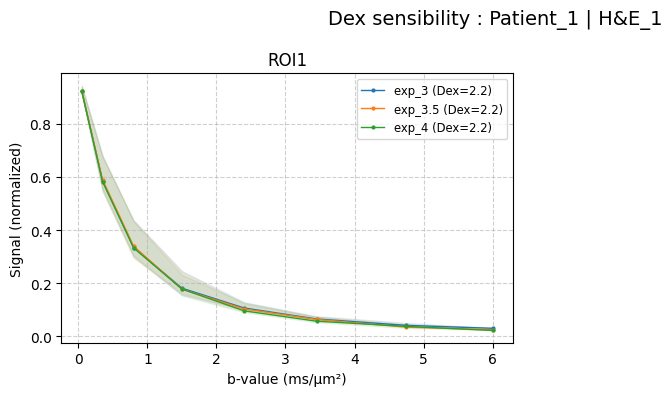

1.5 TD_19 exp_3 ROI1
2.2 TD_19 exp_3 ROI1
2.5 TD_19 exp_3 ROI1
1.5 TD_19 exp_3.5 ROI1
2.2 TD_19 exp_3.5 ROI1
2.5 TD_19 exp_3.5 ROI1
1.5 TD_19 exp_4 ROI1
2.2 TD_19 exp_4 ROI1
2.5 TD_19 exp_4 ROI1
1.5 TD_19 exp_3 ROI2
2.2 TD_19 exp_3 ROI2
2.5 TD_19 exp_3 ROI2
1.5 TD_19 exp_3.5 ROI2
2.2 TD_19 exp_3.5 ROI2
2.5 TD_19 exp_3.5 ROI2
1.5 TD_19 exp_4 ROI2
2.2 TD_19 exp_4 ROI2
2.5 TD_19 exp_4 ROI2
1.5 TD_19 exp_3 ROI3
2.2 TD_19 exp_3 ROI3
2.5 TD_19 exp_3 ROI3
1.5 TD_19 exp_3.5 ROI3
2.2 TD_19 exp_3.5 ROI3
2.5 TD_19 exp_3.5 ROI3
1.5 TD_19 exp_4 ROI3
2.2 TD_19 exp_4 ROI3
2.5 TD_19 exp_4 ROI3


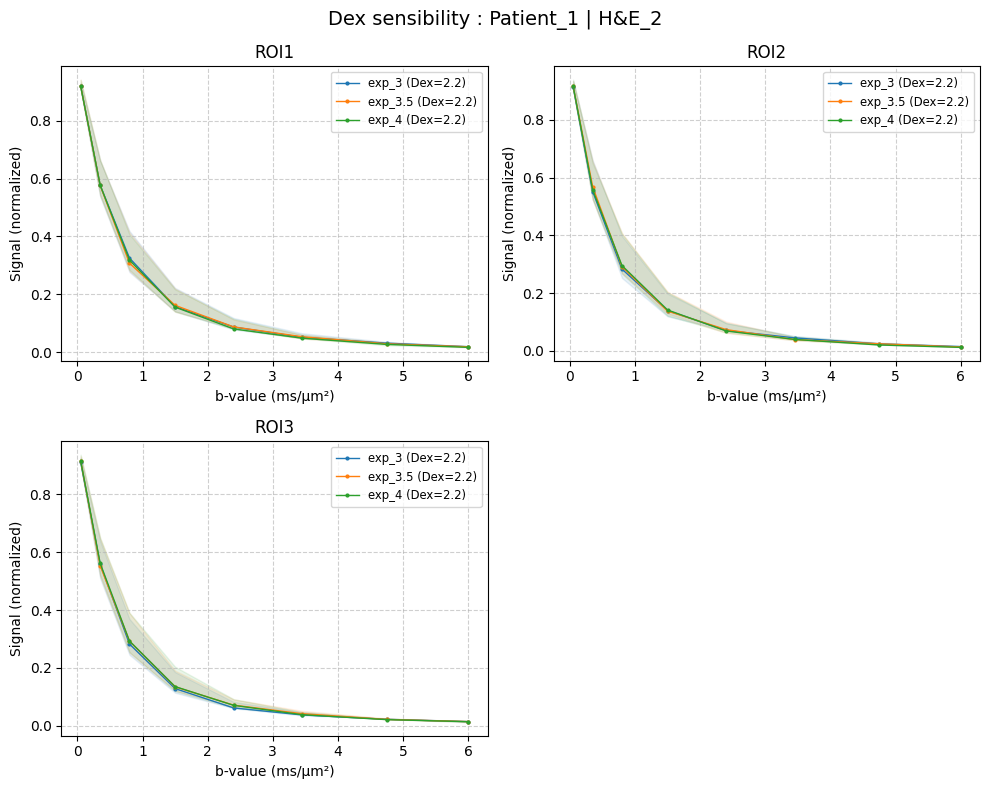

1.5 TD_19 exp_3 ROI1
2.2 TD_19 exp_3 ROI1
2.5 TD_19 exp_3 ROI1
1.5 TD_19 exp_3.5 ROI1
2.2 TD_19 exp_3.5 ROI1
2.5 TD_19 exp_3.5 ROI1
1.5 TD_19 exp_4 ROI1
2.2 TD_19 exp_4 ROI1
2.5 TD_19 exp_4 ROI1
1.5 TD_19 exp_3 ROI2
2.2 TD_19 exp_3 ROI2
2.5 TD_19 exp_3 ROI2
1.5 TD_19 exp_3.5 ROI2
2.2 TD_19 exp_3.5 ROI2
2.5 TD_19 exp_3.5 ROI2
1.5 TD_19 exp_4 ROI2
2.2 TD_19 exp_4 ROI2
2.5 TD_19 exp_4 ROI2
1.5 TD_19 exp_3 ROI3
2.2 TD_19 exp_3 ROI3
2.5 TD_19 exp_3 ROI3
1.5 TD_19 exp_3.5 ROI3
2.2 TD_19 exp_3.5 ROI3
2.5 TD_19 exp_3.5 ROI3
1.5 TD_19 exp_4 ROI3
2.2 TD_19 exp_4 ROI3
2.5 TD_19 exp_4 ROI3
1.5 TD_19 exp_3 ROI4
2.2 TD_19 exp_3 ROI4
2.5 TD_19 exp_3 ROI4
1.5 TD_19 exp_3.5 ROI4
2.2 TD_19 exp_3.5 ROI4
2.5 TD_19 exp_3.5 ROI4
1.5 TD_19 exp_4 ROI4
2.2 TD_19 exp_4 ROI4
2.5 TD_19 exp_4 ROI4


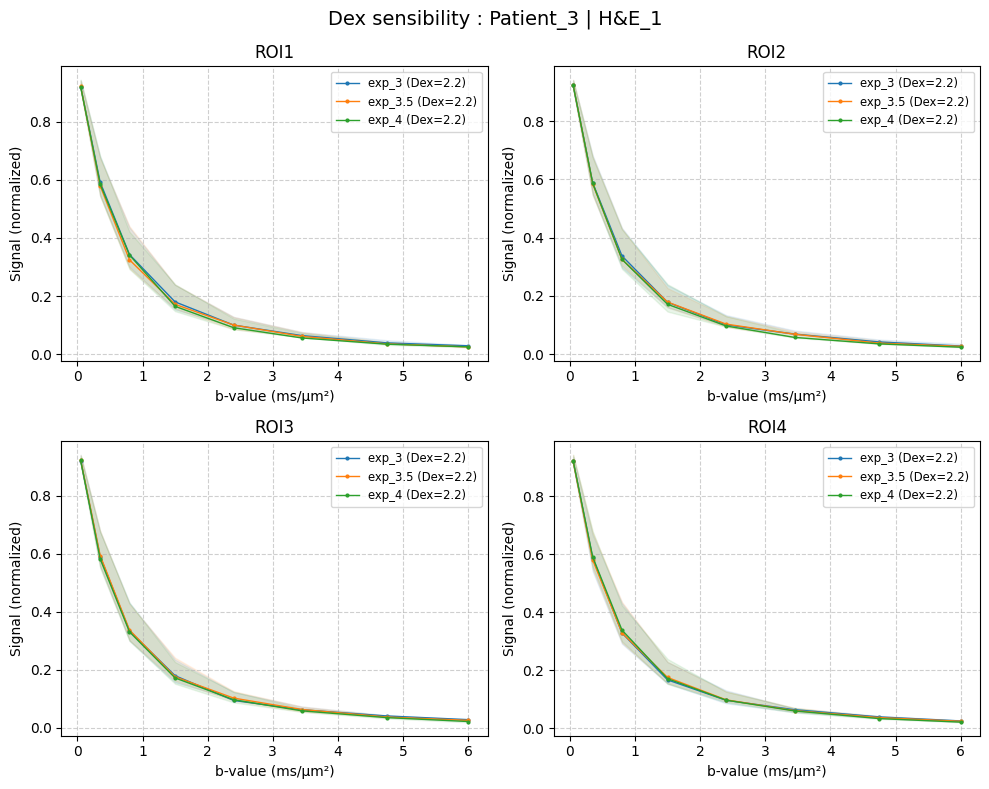

In [60]:
Dex_min = 1.5
Dex_central = 2.2
Dex_max = 2.5
Dex_options = [Dex_min, Dex_central, Dex_max]

exp_colors = ['tab:blue', 'tab:orange', 'tab:green']

for pat_id in signal_json.keys():
    for he in signal_json[pat_id].keys():
        #print(json.dumps(signal_json[pat_id][he], indent=4, ensure_ascii=False))
        roi_list = list(
            signal_json[pat_id][he][list(signal_json[pat_id][he].keys())[0]].keys()
        )
        #print(roi_list)

        if len(roi_list) == 0:
            continue  

        ncols = 2
        nrows = math.ceil(len(roi_list) / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4*nrows))
        axes = axes.flatten()

        for r_idx, roi_name in enumerate(roi_list):

            ax = axes[r_idx]

            for idx, exp2 in enumerate(signal_json[pat_id][he].keys()):
                color = exp_colors[idx]
                TD_key = list(signal_json[pat_id][he][exp2][roi_name].keys())[0]

                signals = {}

                for Dex in Dex_options:
                    print(Dex, TD_key, exp2, roi_name)
                    data = signal_json[pat_id][he][exp2][roi_name][TD_key][f"Dex_{Dex}"]
                    bvals = np.array(data['bval'])
                    signals[Dex] = np.array(data['signals_mean'])

                ax.plot(
                    bvals,
                    signals[Dex_central],
                    color=color,
                    linewidth=1,
                    marker='o',
                    markersize=2,
                    label=f"{exp2} (Dex={Dex_central})"
                )

                ax.fill_between(
                    bvals,
                    signals[Dex_min],
                    signals[Dex_max],
                    color=color,
                    alpha=0.1
                )

            ax.legend(loc='upper right', fontsize='small')
            ax.set_xlabel("b-value (ms/µm²)")
            ax.set_ylabel("Signal (normalized)")
            ax.set_title(f"{roi_name}")
            ax.grid(True, linestyle='--', alpha=0.6)

        for j in range(len(roi_list), len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"Dex sensibility : {pat_id} | {he}", fontsize=14)
        fig.tight_layout()
        plt.show()

# Display exp decrease : compare ROIs

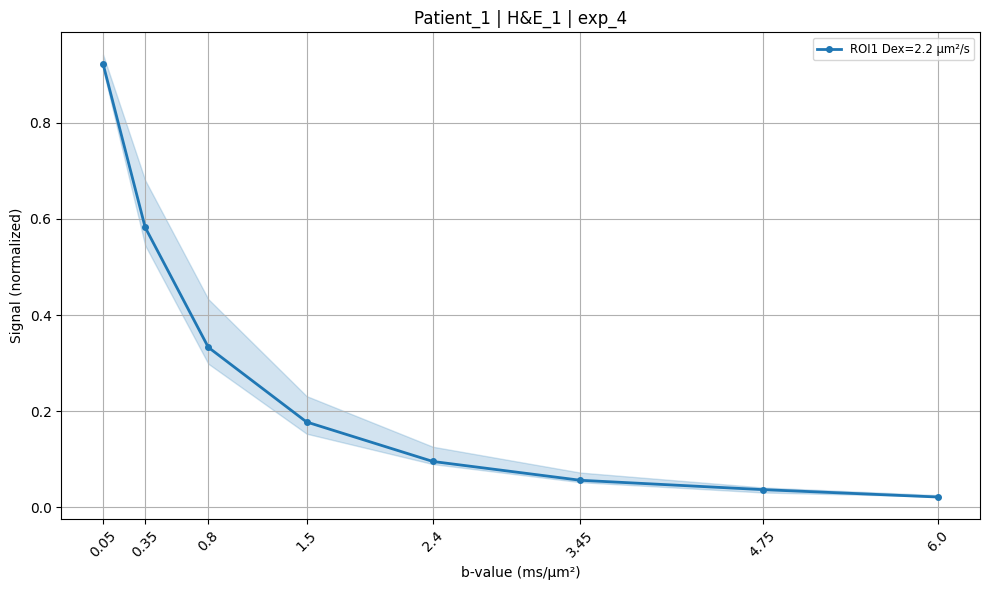

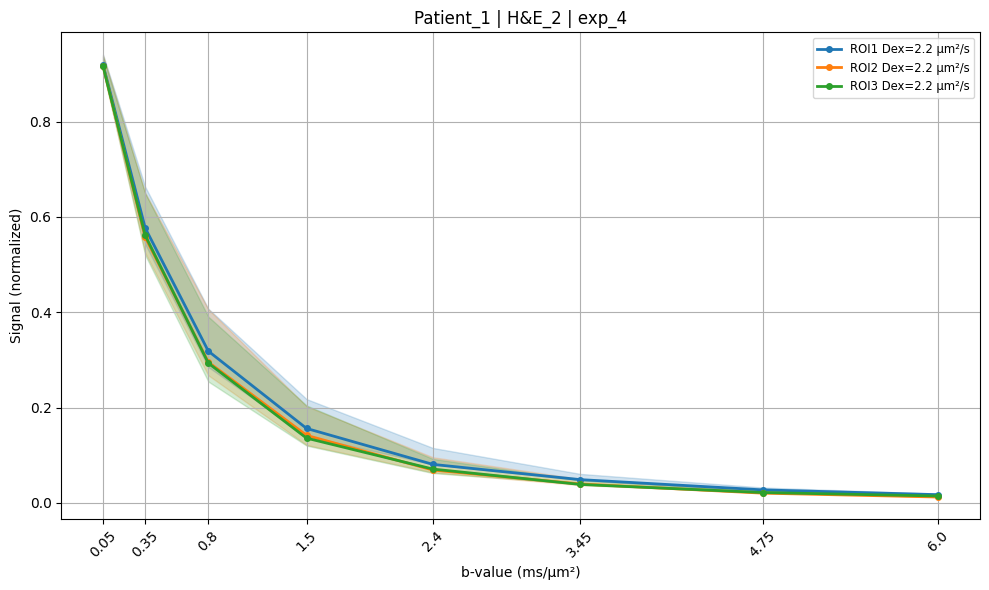

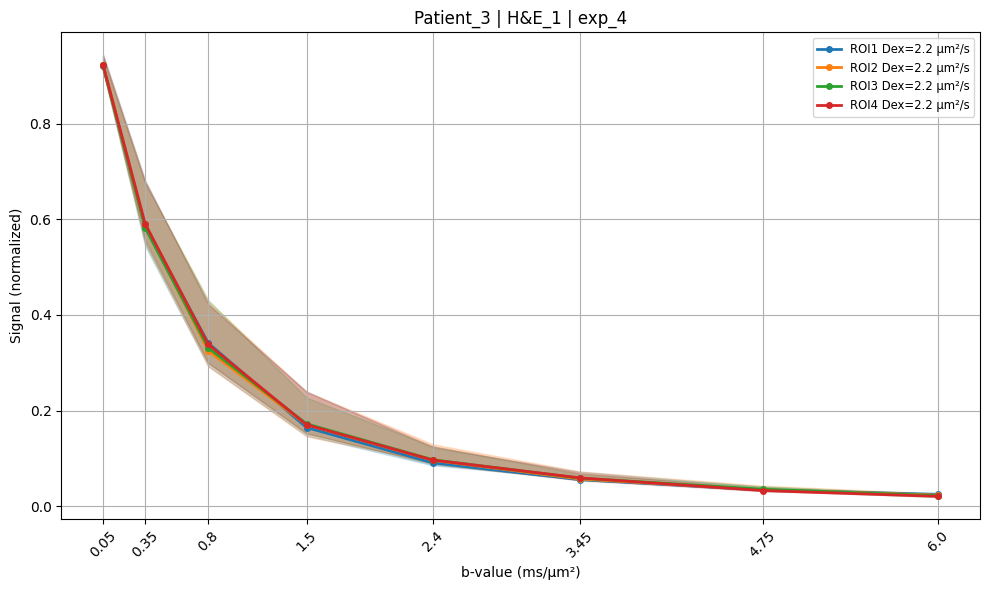

C:\Users\maely\AppData\Local\Temp\ipykernel_25404\2761903099.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')


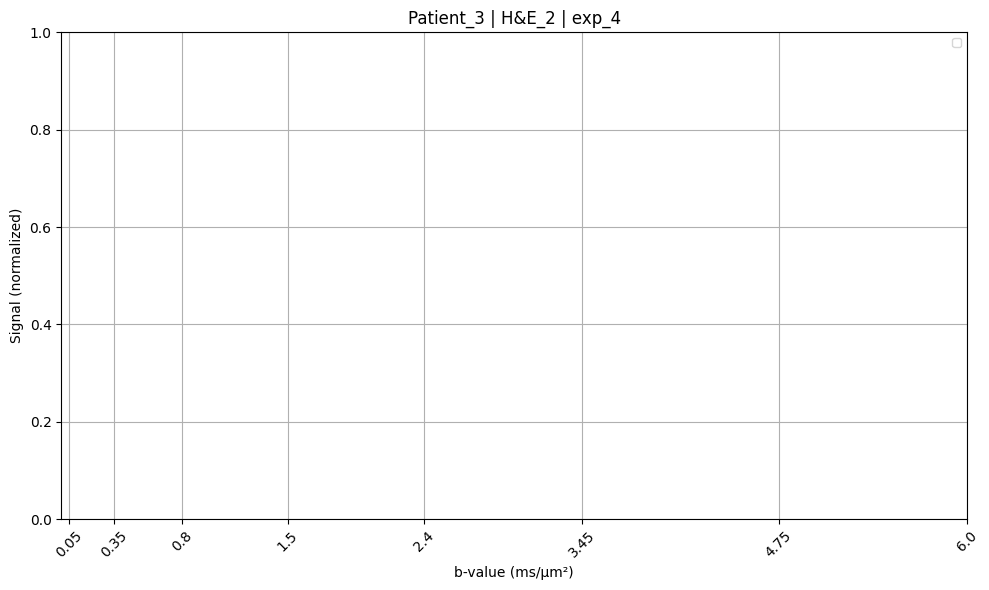

In [61]:
exp_selected = 'exp_4'

# Dex envelope
Dex_min = 1.5
Dex_central = 2.2
Dex_max = 2.5
Dex_options = [Dex_min, Dex_central, Dex_max]

# Colors for ROIs
roi_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:cyan', 'tab:brown']

for pat_id in signal_json.keys():
    for he in signal_json[pat_id].keys():

        # Nouvelle figure unique
        fig, ax = plt.subplots(figsize=(10,6))
        ax.set_title(f"{pat_id} | {he} | {exp_selected}")
        ax.set_xlabel("b-value (ms/µm²)")
        ax.set_ylabel("Signal (normalized)")
        ax.grid(True)

        # ROIs
        roi_names = list(signal_json[pat_id][he][exp_selected].keys())

        for idx, roi_name in enumerate(roi_names):
            color = roi_colors[idx % len(roi_colors)]

            # TD key
            TD_keys = list(signal_json[pat_id][he][exp_selected][roi_name].keys())
            TD_key = TD_keys[0]

            # Get signal
            signals = {}
            for Dex in Dex_options:
                data = signal_json[pat_id][he][exp_selected][roi_name][TD_key][f"Dex_{Dex}"]
                bvals = np.array(data['bval'])
                signals[Dex] = np.array(data['signals_mean'])

            # Central curve
            ax.plot(bvals, signals[Dex_central], color=color, linewidth=2,
                    marker='o', markersize=4,
                    label=f"{roi_name} Dex={Dex_central} µm²/s")

            # Dex
            ax.fill_between(bvals, signals[Dex_min], signals[Dex_max], color=color, alpha=0.2)

        ax.legend(fontsize='small', loc='upper right')
        ax.set_xticks(bvals)
        ax.set_xticklabels([str(b) for b in bvals], rotation=45)
        plt.tight_layout()
        plt.show()

# Exp decay : comparison between diffusion times

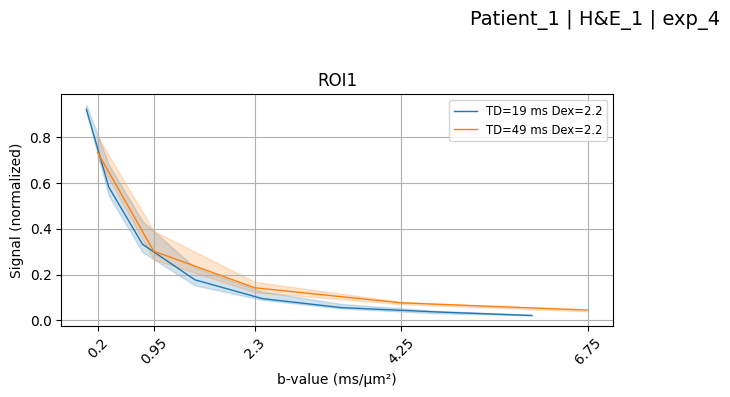

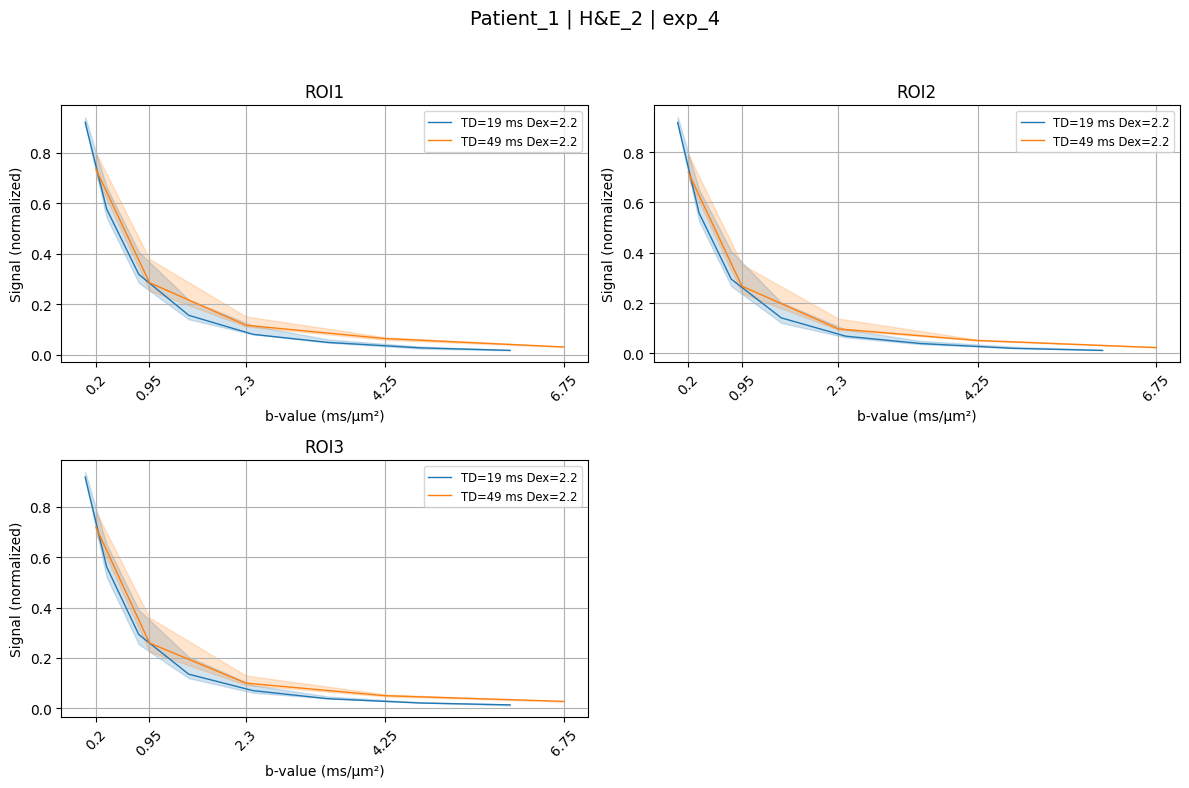

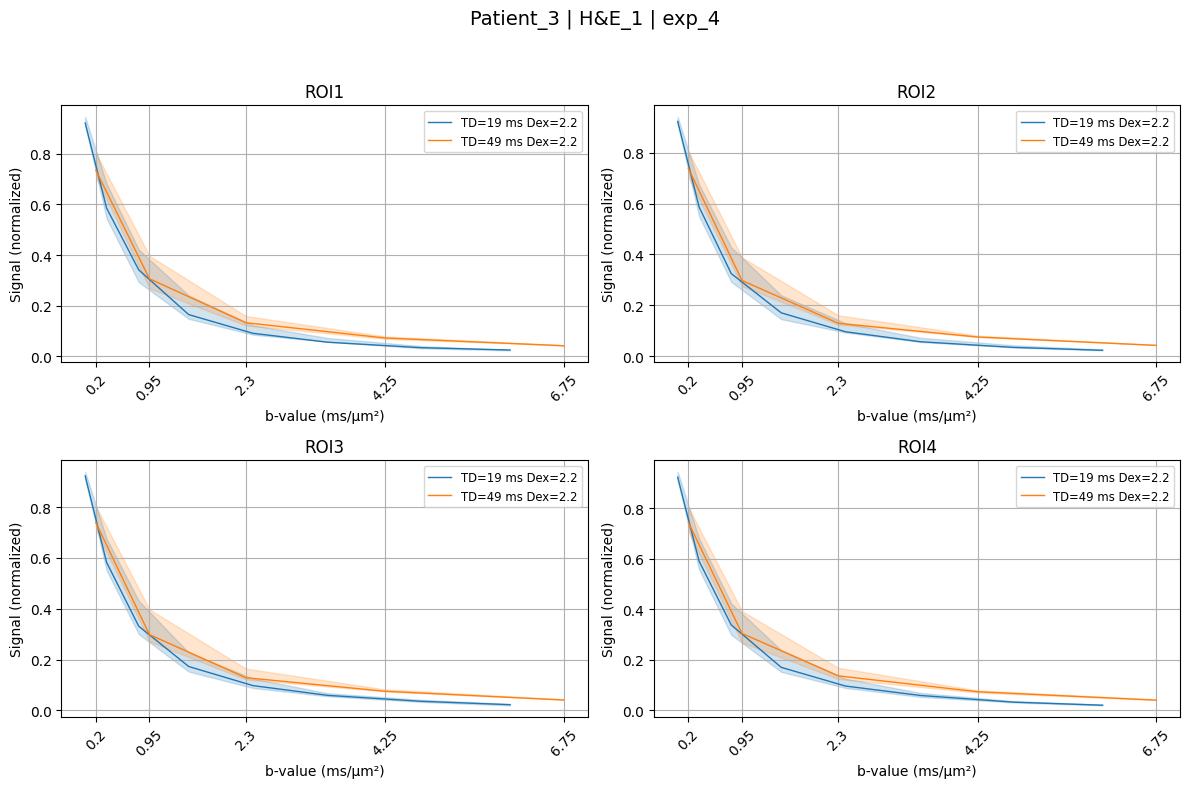

In [ ]:
exp_selected = 'exp_4'

# Dex envelope
Dex_min = 1.5
Dex_central = 2.2
Dex_max = 2.5
Dex_options = [Dex_min, Dex_central, Dex_max]

# Colors for TDs within each ROI
TD_colors = ['tab:blue', 'tab:orange']

# Colors for ROIs (just in case tu veux les harmoniser)
roi_colors = ['tab:green', 'tab:red', 'tab:purple', 'tab:cyan', 'tab:brown']

for pat_id in signal_json.keys():
    for he in signal_json[pat_id].keys():

        # Liste des ROIs pour l'exp sélectionné
        roi_names = list(signal_json[pat_id][he][exp_selected].keys())
        n_rois = len(roi_names)
        if n_rois == 0:
            continue

        # Déterminer le nombre de lignes et colonnes pour 2 colonnes
        ncols = 2
        nrows = math.ceil(n_rois / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
        axes = axes.flatten()  # faciliter l'itération

        for idx, roi_name in enumerate(roi_names):
            ax = axes[idx]
            ax.set_title(f"{roi_name}")
            ax.set_xlabel("b-value (ms/µm²)")
            ax.set_ylabel("Signal (normalized)")
            ax.grid(True)

            # TD keys
            TD_keys = list(signal_json[pat_id][he][exp_selected][roi_name].keys())

            for td_idx, TD_key in enumerate(TD_keys):
                color = TD_colors[td_idx % len(TD_colors)]
                bvals = []
                signals_central = []
                signals_min = []
                signals_max = []

                for Dex in Dex_options:
                    data = signal_json[pat_id][he][exp_selected][roi_name][TD_key][f"Dex_{Dex}"]
                    bvals_all = np.array(data['bval'])
                    signal_vals_all = np.array(data['signals_mean'])

                    # Filter bvals < 7.5
                    mask = bvals_all < 7.5
                    bvals_filtered = bvals_all[mask]
                    signal_vals_filtered = signal_vals_all[mask]

                    if Dex == Dex_central:
                        signals_central = signal_vals_filtered
                        bvals = bvals_filtered
                    elif Dex <= Dex_min:
                        signals_min = signal_vals_filtered
                    elif Dex >= Dex_max:
                        signals_max = signal_vals_filtered

                # Central curve
                ax.plot(bvals, signals_central, color=color, linewidth=1,
                        label=f"TD={TD_key.split('_')[1]} ms Dex={Dex_central}")

                # Dex envelope
                if len(signals_min) > 0 and len(signals_max) > 0:
                    ax.fill_between(bvals, signals_min, signals_max, color=color, alpha=0.2)

            ax.legend(fontsize='small')
            ax.set_xticks(bvals)
            ax.set_xticklabels([str(b) for b in bvals], rotation=45)

        for j in range(n_rois, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"{pat_id} | {he} | {exp_selected}", fontsize=14)
        plt.tight_layout(rect=[0,0,1,0.95])
        plt.show()

# Exponential decay for each patient

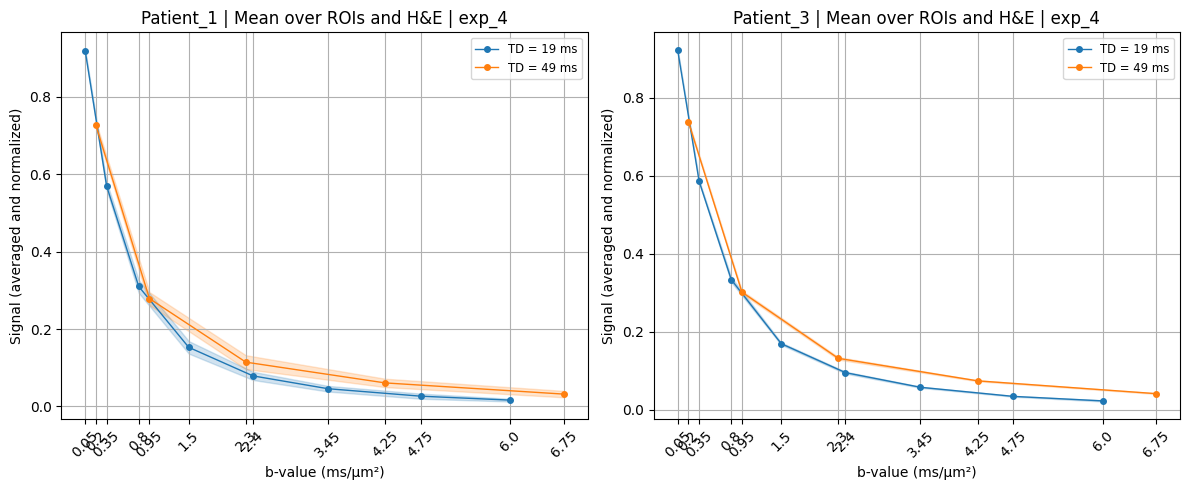

In [ ]:
exp_selected = "exp_4"
Dex_central = 2.2
bval_max = 7.5
TD_colors = ['tab:blue', 'tab:orange']

pat_ids = list(signal_json.keys())
n_pats = len(pat_ids)

# Determine grid layout (2 columns max)
ncols = min(2, n_pats)
nrows = int(np.ceil(n_pats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = np.array(axes).flatten()  # flatten in case of multiple rows

for ax_idx, pat_id in enumerate(pat_ids):
    ax = axes[ax_idx]

    # Dictionary to store signals per TD and b-value
    td_bval_signals = {}
    all_bvals = set()

    # --- Aggregate signals over all ROIs and H&Es ---
    for he in signal_json[pat_id].keys():
        if exp_selected not in signal_json[pat_id][he]:
            continue
        for roi_name in signal_json[pat_id][he][exp_selected].keys():
            for TD_key in signal_json[pat_id][he][exp_selected][roi_name].keys():
                if TD_key not in td_bval_signals:
                    td_bval_signals[TD_key] = {}

                # Extract mean signals for the selected Dex
                data = signal_json[pat_id][he][exp_selected][roi_name][TD_key][f"Dex_{Dex_central}"]
                bvals = np.array(data["bval"])
                signals = np.array(data["signals_mean"])

                # Filter b-values below max
                mask = bvals < bval_max
                bvals = bvals[mask]
                signals = signals[mask]

                all_bvals.update(bvals.tolist())

                # Append signals per b-value
                for b, s in zip(bvals, signals):
                    td_bval_signals[TD_key].setdefault(b, []).append(s)

    all_bvals = sorted(all_bvals)

    # --- Plot for each TD ---
    for td_idx, TD_key in enumerate(sorted(td_bval_signals.keys())):
        bvals_sorted = sorted(td_bval_signals[TD_key].keys())
        
        mean_signals = []
        std_signals = []
        bvals_used = []

        # Only include b-values with actual data
        for b in bvals_sorted:
            signals_list = td_bval_signals[TD_key][b]
            if len(signals_list) > 0:
                mean_signals.append(np.mean(signals_list))
                std_signals.append(np.std(signals_list))
                bvals_used.append(b)

        mean_signals = np.array(mean_signals)
        std_signals = np.array(std_signals)
        bvals_used = np.array(bvals_used)

        color = TD_colors[td_idx % len(TD_colors)]

        # Plot mean signal
        ax.plot(bvals_used, mean_signals, marker='o', markersize=4,
                linewidth=1, label=f"TD = {TD_key.split('_')[1]} ms", color=color)
        # Plot envelope ± std
        ax.fill_between(bvals_used, mean_signals - std_signals, mean_signals + std_signals,
                        color=color, alpha=0.2)

    ax.set_title(f"{pat_id} | Mean over ROIs and H&E | {exp_selected}")
    ax.set_xlabel("b-value (ms/µm²)")
    ax.set_ylabel("Signal (averaged and normalized)")
    ax.grid(True)
    ax.legend(fontsize='small')

    # Optional: set all x-ticks to the union of b-values
    ax.set_xticks(all_bvals)
    ax.set_xticklabels([str(round(b, 2)) for b in all_bvals], rotation=45)

# Remove empty axes if there are fewer patients than subplots
for j in range(len(pat_ids), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# All std (ROIs + parameters)

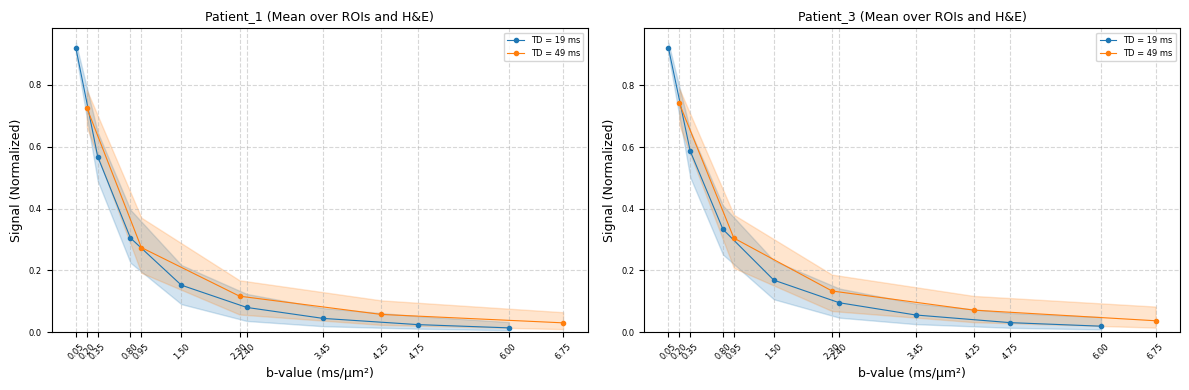

In [ ]:
exp_selected = "exp_4"
Dex_central = 2.2
bval_max = 7.5
TD_colors = ['tab:blue', 'tab:orange']

pat_ids = list(signal_json.keys())
n_pats = len(pat_ids)

ncols = min(2, n_pats)  
nrows = int(np.ceil(n_pats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.array(axes).flatten()  

for ax_idx, pat_id in enumerate(pat_ids):
    ax = axes[ax_idx]

    td_bval_agg = {}
    all_bvals = set()

    for he in signal_json[pat_id].keys():
        if exp_selected not in signal_json[pat_id][he]:
            continue
            
        for roi_name in signal_json[pat_id][he][exp_selected].keys():
            roi_data = signal_json[pat_id][he][exp_selected][roi_name]
            
            for TD_key in roi_data.keys():
                if TD_key not in td_bval_agg:
                    td_bval_agg[TD_key] = {}

                dex_key = f"Dex_{Dex_central}"
                if dex_key not in roi_data[TD_key]:
                    continue
                    
                data = roi_data[TD_key][dex_key]
                bvals = np.array(data["bval"])
                signals = np.array(data["signals_median"])
                p_lows = np.array(data["p_low"])
                p_highs = np.array(data["p_high"])

                # Max b-value filtering
                mask = bvals < bval_max
                all_bvals.update(bvals[mask].tolist())

                # Aggregation
                for b, s, low, high in zip(bvals[mask], signals[mask], p_lows[mask], p_highs[mask]):
                    if b not in td_bval_agg[TD_key]:
                        td_bval_agg[TD_key][b] = {'s_vals': [], 'low_vals': [], 'high_vals': []}
                    td_bval_agg[TD_key][b]['s_vals'].append(s)
                    td_bval_agg[TD_key][b]['low_vals'].append(low)
                    td_bval_agg[TD_key][b]['high_vals'].append(high)

    all_bvals_sorted = sorted(list(all_bvals))

    # Plot for each TD with aggregated mean and uncertainty
    for td_idx, TD_key in enumerate(sorted(td_bval_agg.keys())):
        bvals_plot = sorted(td_bval_agg[TD_key].keys())
        final_medians = [np.mean(td_bval_agg[TD_key][b]['s_vals']) for b in bvals_plot]
        final_lows = [np.mean(td_bval_agg[TD_key][b]['low_vals']) for b in bvals_plot]
        final_highs = [np.mean(td_bval_agg[TD_key][b]['high_vals']) for b in bvals_plot]

        color = TD_colors[td_idx % len(TD_colors)]
        label = f"TD = {TD_key.split('_')[1]} ms"

        ax.plot(bvals_plot, final_medians, marker='o', markersize=3, color=color,
                label=label, linewidth=0.8)
        ax.fill_between(bvals_plot, final_lows, final_highs, color=color, alpha=0.2)

    ax.set_title(f"{pat_id} (Mean over ROIs and H&E)", fontsize=9)
    ax.set_xlabel("b-value (ms/µm²)", fontsize=9)
    ax.set_ylabel("Signal (Normalized)", fontsize=9)
    ax.set_ylim(bottom=0)
    ax.set_xticks(all_bvals_sorted)
    ax.set_xticklabels([f"{x:.2f}" for x in all_bvals_sorted], rotation=45)
    ax.tick_params(axis='both', which='major', labelsize=6)
    ax.tick_params(axis='both', which='minor', labelsize=5)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(fontsize=6)

for j in range(len(pat_ids), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()